In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import numpy as np
import pickle

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file, get_project_path
from flonacomldft.sampling import run_metropolis
from flonacomldft.utils.diagnostics import get_ESS, avg_windows
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

# from flonacomldft.train_flow_from_data import get_ratio_acc
from flonacomldft.free_energy_computations import (
    compute_TFP_logratio, compute_deepBAR_logratio,
    compute_TFP, compute_BAR
)

from ase.units import kB
import matplotlib.pylab as pylab

size=12
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [2]:
coord_mapping = Coordinates_mapping()
T = 300

In [6]:
project_path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_2/"

number_ids = [25346510, 25551260, 25551261, 25697181]

get_folder = lambda number_id:"results_multimodal_sampling_mixture_{:d}/mixture_mcmc_dic_{:d}.pkl".format(number_id, number_id)

### 1.a Computing the Rhat convergence criteria

In [7]:
import arviz as az
from arviz.utils import get_coords, _var_names

In [8]:
def plot_Rhat(folder, project_path):
    
    dict_results_mh = load_pickle_file(folder, project_path)
    xs_np = dict_results_mh["xs"].detach().numpy()
    xs_np = xs_np.transpose(1, 0, 2)
        
    isomers_np = dict_results_mh["isomers"].detach().numpy()
    isomers_np = isomers_np.transpose(1, 0)

    zmat_np = torch.zeros(xs_np.shape)

    print(xs_np.shape)

    for i in range(xs_np.shape[1]):
        for j in range(xs_np.shape[0]):
            zmat_np[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs_np[j, i]).reshape(1, -1), 
                                                                      isomer=isomers_np[j, i])[0]
    zmat_np = zmat_np.detach().numpy()
    
    burn_in = 100

    idata = az.convert_to_inference_data(zmat_np[:, burn_in:, :])
    coords = {}
    data = get_coords(az.convert_to_dataset(idata, group="posterior"), coords)
    var_names = None
    filter_vars = None

    var_names = _var_names(var_names, data, filter_vars)
    n_draws = data.dims["draw"]
    n_samples = n_draws * data.dims["chain"]
    first_draw = data.draw.values[0] # int of where where things should start
    labels = ['x{:d}'.format(i) for i in range(12)]

    ## Compute where to split the data to diagnostic the convergence
    n_split = 10
    xdata = np.linspace(n_samples / n_split, n_samples, n_split)
    draw_divisions = np.linspace(n_draws // n_split, n_draws, n_split, dtype=int)

    rhat_s = np.stack([np.array(az.rhat(data.sel(draw=slice(first_draw + draw_div)),
                    var_names=var_names,
                    method="rank",
                )['x'])
        for draw_div in draw_divisions
        ])

    fig, axs = plt.subplots(1, 2, figsize=(18, 7))
    
    axs[0].plot(draw_divisions, rhat_s, '-o',  label=labels)
    axs[0].axhline(1, c='k', ls='--')
    axs[0].axhline(1.01, c='grey', ls='--')
    axs[0].set_xlabel('Iteration')
    axs[0].set_ylabel(r'$\hat{R}$')
    axs[0].legend()

    # plot isomers populations and weights if availables

    isomers = dict_results_mh["isomers"]
    population_is0_mean = (~isomers.bool()).float().mean()
    population_is0 = [(~isomers[:i].bool()).float().mean().item() for i in range(isomers.shape[0])]

    
    axs[1].plot(population_is0, label="population is0")
    axs[1].axhline(population_is0_mean, color='r', linestyle=':', alpha=0.5, label="mean population is0 {:.3f}".format(population_is0_mean))

    if "weights" in dict_results_mh.keys():
        weights = dict_results_mh["weights"]
        axs[1].plot(weights[:, 0], '--', label="weights")
    
    axs[1].set_ylim(0.95, 1)
    axs[1].set_xlabel("MCMC steps")
    axs[1].set_ylabel("Population")
    
    axs[1].legend()

    
    fig.suptitle("Chains: {:d}, Steps: {:d}".format(dict_results_mh["args"]["n_chains"], 
                                                    dict_results_mh["args"]["n_steps"]), fontsize=16)
    
    return dict_results_mh

(50, 350, 12)
(50, 500, 12)
(100, 500, 12)
(100, 1000, 12)


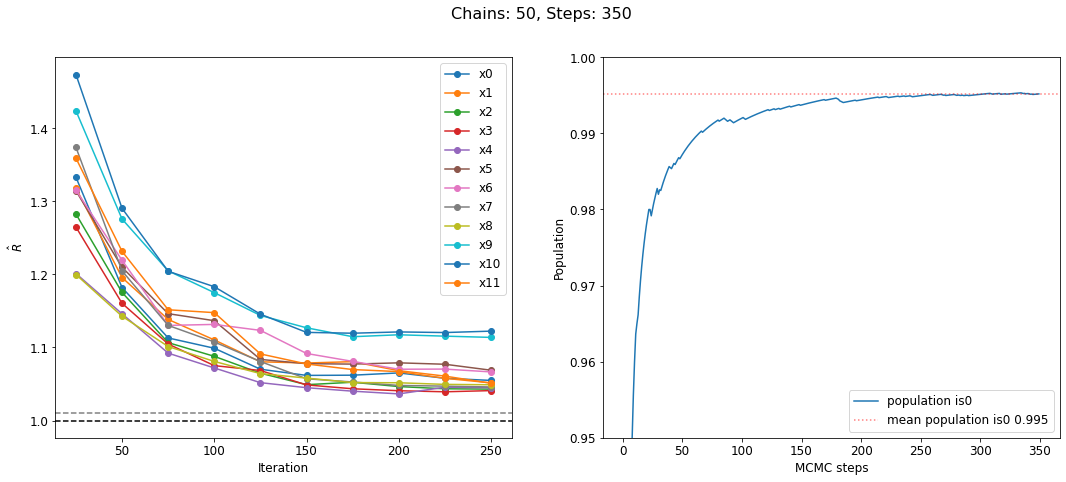

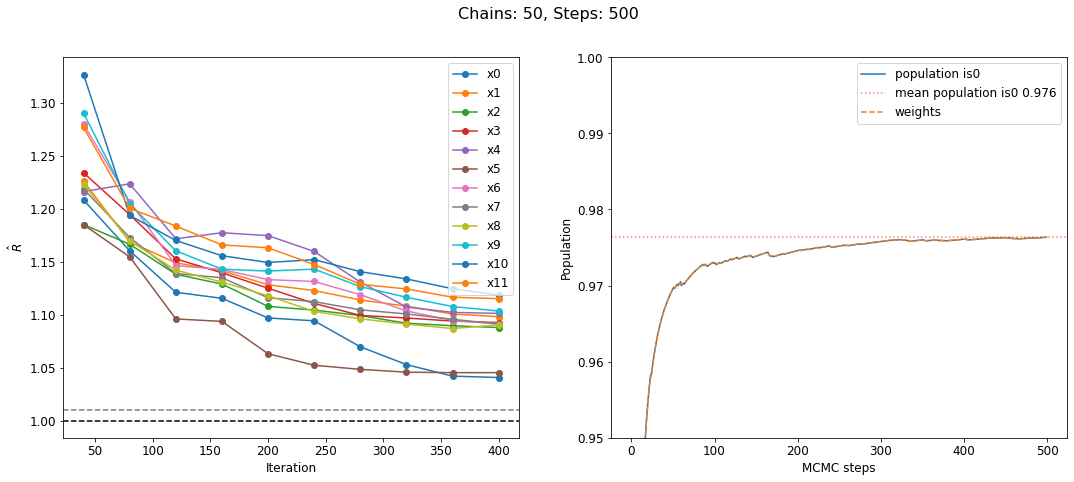

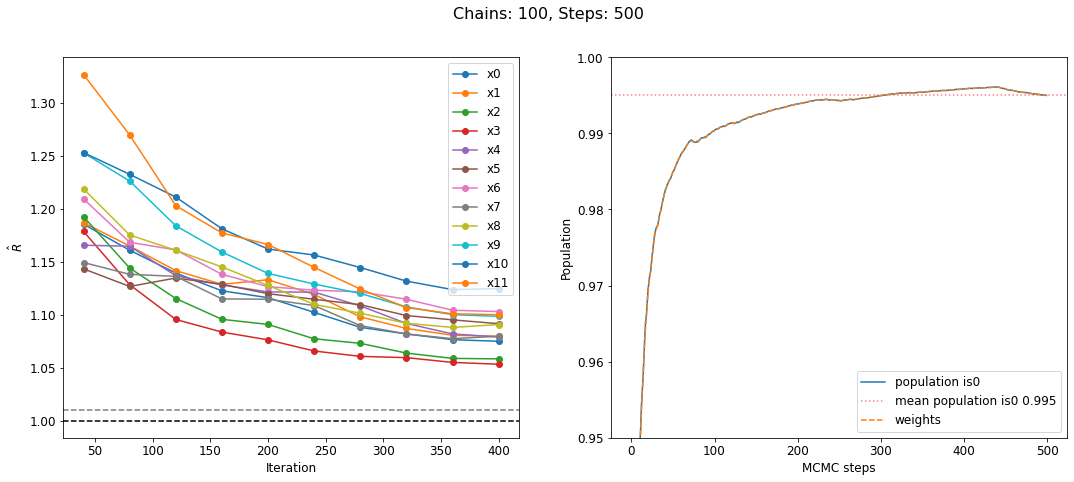

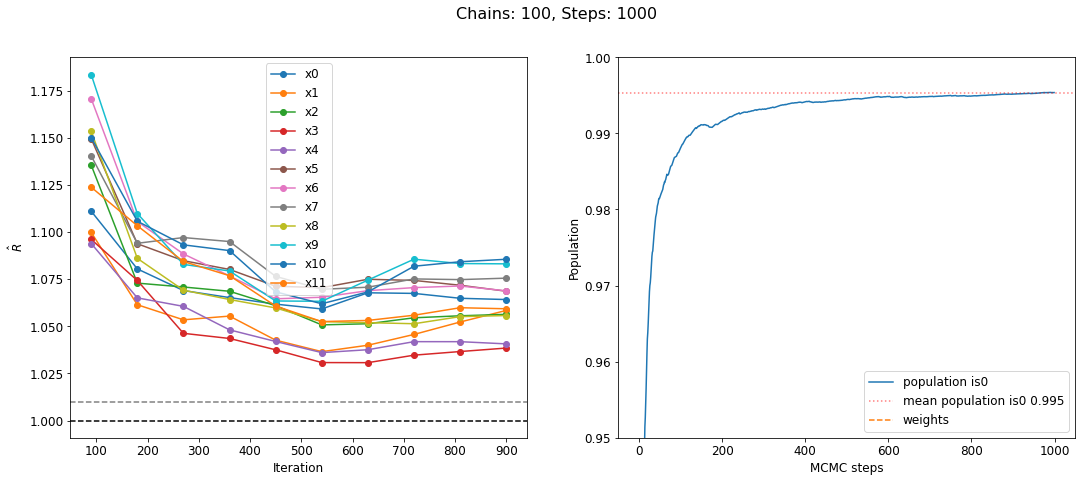

In [9]:
dics_mcmc_mixture = [plot_Rhat(get_folder(number_id), project_path) for number_id in number_ids]

In [14]:
accs = [dics_mcmc_mixture[i]["accs"].mean(dim=1) for i in range(len(number_ids))]

Text(0, 0.5, 'Acceptance ratio')

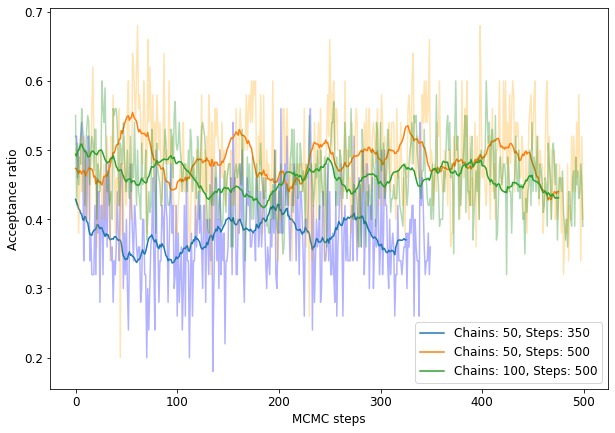

In [11]:
fig, ax =  plt.subplots(1, 1, figsize=(10, 7))

c = ['b', 'orange', 'g']

for i in range(len(accs)):
    
    ax.plot(accs[i], c=c[i], alpha=0.3)
    ax.plot(avg_windows(accs[i], 25, 1), label="Chains: {:d}, Steps: {:d}".format(dics_mcmc_mixture[i]["args"]["n_chains"], 
                                                    dics_mcmc_mixture[i]["args"]["n_steps"]) )
    
ax.legend()
ax.set_xlabel("MCMC steps")
ax.set_ylabel("Acceptance ratio")